# 🎬 Automatic Video Highlight Generator
### Using CLIP-based Scene Scoring + Temporal Segmentation

**Pipeline:**
1. Download TVSum dataset directly
2. Extract frames from a video
3. Score each frame using CLIP against highlight-related prompts
4. Pick top-scoring segments
5. Stitch into a highlight clip using MoviePy
6. Summarize with BART (optional)

> ✅ No paid APIs. All free models. Runs fully on Kaggle GPU.

## Step 1 — Install Dependencies

In [1]:
%%capture
!pip install transformers moviepy ftfy regex tqdm Pillow torch torchvision --quiet
print('✅ All dependencies installed.')

## Step 2 — Download TVSum Dataset

In [6]:
import os

print("📥 Downloading TVSum dataset...")

# Remove old/corrupted files
!rm -f tvsum50_ver_1_1.tgz

# Download
!wget -c http://people.csail.mit.edu/yalesong/tvsum/tvsum50_ver_1_1.tgz

print("✅ Download complete")

# Extract
!tar -xvzf tvsum50_ver_1_1.tgz

print("✅ Extraction complete")

# Check contents
!ls

📥 Downloading TVSum dataset...
--2026-05-20 11:57:48--  http://people.csail.mit.edu/yalesong/tvsum/tvsum50_ver_1_1.tgz
Resolving people.csail.mit.edu (people.csail.mit.edu)... 128.52.131.233
Connecting to people.csail.mit.edu (people.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://people.csail.mit.edu/yalesong/tvsum/tvsum50_ver_1_1.tgz [following]
--2026-05-20 11:57:48--  https://people.csail.mit.edu/yalesong/tvsum/tvsum50_ver_1_1.tgz
Connecting to people.csail.mit.edu (people.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 671779858 (641M) [application/x-gzip]
Saving to: ‘tvsum50_ver_1_1.tgz’

tvsum50_ver_1_1.tgz 100%[===================>] 640.66M  10.5MB/s    in 60s     

2026-05-20 11:58:48 (10.7 MB/s) - ‘tvsum50_ver_1_1.tgz’ saved [671779858/671779858]

✅ Download complete
./WebscopeReadMe.txt
./ydata-tvsum50-v1_1/
./ydata-tvsum50-v1_1/README
./yda

In [8]:
!ls ydata-tvsum50-v1_1

README			ydata-tvsum50-matlab.zip     ydata-tvsum50-video.zip
ydata-tvsum50-data.zip	ydata-tvsum50-thumbnail.zip


In [9]:
# Extract annotation data
!unzip -q ydata-tvsum50-v1_1/ydata-tvsum50-data.zip -d tvsum_data

In [10]:
# Extract videos
!unzip -q ydata-tvsum50-v1_1/ydata-tvsum50-video.zip -d tvsum_videos

In [11]:
# Extract thumbnails
!unzip -q ydata-tvsum50-v1_1/ydata-tvsum50-thumbnail.zip -d tvsum_thumbnails

In [12]:
# Extract matlab files
!unzip -q ydata-tvsum50-v1_1/ydata-tvsum50-matlab.zip -d tvsum_matlab

In [13]:
!ls


tvsum50_ver_1_1.tgz  tvsum_matlab      tvsum_videos	   ydata-tvsum50-v1_1
tvsum_data	     tvsum_thumbnails  WebscopeReadMe.txt


In [15]:
!ls  tvsum_videos/video

0tmA_C6XwfM.mp4  EE-bNr36nyA.mp4  JgHubY5Vw3Y.mp4  VuWGsYPqAX8.mp4
37rzWOQsNIw.mp4  eQu1rNs0an0.mp4  JKpqYvAdIsw.mp4  WG0MBPpPC6I.mp4
3eYKfiOEJNs.mp4  -esJrBWj2d8.mp4  kLxoNp-UchI.mp4  WxtbjNsCQ8A.mp4
4wU_LUjG5Ic.mp4  EYqVtI9YWJA.mp4  LRw_obCPUt0.mp4  XkqCExn6_Us.mp4
91IHQYk1IQM.mp4  fWutDQy1nnY.mp4  NyBmCxDoHJU.mp4  xmEERLqJ2kU.mp4
98MoyGZKHXc.mp4  GsAD1KT1xo8.mp4  oDXZc0tZe04.mp4  _xMr-HKMfVA.mp4
akI8YFjEmUw.mp4  gzDbaEs1Rlg.mp4  PJrm840pAUI.mp4  xwqBXPGE9pQ.mp4
AwmHb44_ouw.mp4  Hl-__g2gn_A.mp4  qqR6AEXwxoQ.mp4  xxdtq8mxegs.mp4
b626MiF1ew4.mp4  HT5vyqe0Xaw.mp4  RBCABdttQmI.mp4  XzYM3PfTM4w.mp4
Bhxk-O1Y7Ho.mp4  i3wAGJaaktw.mp4  Se3oxnaPsz0.mp4  Yi4Ij2NM7U4.mp4
byxOvuiIJV0.mp4  iVt07TCkFM0.mp4  sTEELN-vY30.mp4  z_6gVvQb2d0.mp4
cjibtmSLxQ4.mp4  J0nA4VgnoCo.mp4  uGu_10sucQo.mp4
E11zDS9XGzg.mp4  jcoYJXDG9sw.mp4  vdmoEJ5YbrQ.mp4


In [17]:
!ls tvsum_matlab/matlab

knapsack  script_evaluate_result.m  solve_knapsack.m  ydata-tvsum50.mat


In [18]:
!ls tvsum_data/data

ydata-tvsum50-anno.tsv	ydata-tvsum50-info.tsv


In [21]:
!ls tvsum_thumbnails/thumbnail


0tmA_C6XwfM.jpg  EE-bNr36nyA.jpg  JgHubY5Vw3Y.jpg  VuWGsYPqAX8.jpg
37rzWOQsNIw.jpg  eQu1rNs0an0.jpg  JKpqYvAdIsw.jpg  WG0MBPpPC6I.jpg
3eYKfiOEJNs.jpg  -esJrBWj2d8.jpg  kLxoNp-UchI.jpg  WxtbjNsCQ8A.jpg
4wU_LUjG5Ic.jpg  EYqVtI9YWJA.jpg  LRw_obCPUt0.jpg  XkqCExn6_Us.jpg
91IHQYk1IQM.jpg  fWutDQy1nnY.jpg  NyBmCxDoHJU.jpg  xmEERLqJ2kU.jpg
98MoyGZKHXc.jpg  GsAD1KT1xo8.jpg  oDXZc0tZe04.jpg  _xMr-HKMfVA.jpg
akI8YFjEmUw.jpg  gzDbaEs1Rlg.jpg  PJrm840pAUI.jpg  xwqBXPGE9pQ.jpg
AwmHb44_ouw.jpg  Hl-__g2gn_A.jpg  qqR6AEXwxoQ.jpg  xxdtq8mxegs.jpg
b626MiF1ew4.jpg  HT5vyqe0Xaw.jpg  RBCABdttQmI.jpg  XzYM3PfTM4w.jpg
Bhxk-O1Y7Ho.jpg  i3wAGJaaktw.jpg  Se3oxnaPsz0.jpg  Yi4Ij2NM7U4.jpg
byxOvuiIJV0.jpg  iVt07TCkFM0.jpg  sTEELN-vY30.jpg  z_6gVvQb2d0.jpg
cjibtmSLxQ4.jpg  J0nA4VgnoCo.jpg  uGu_10sucQo.jpg
E11zDS9XGzg.jpg  jcoYJXDG9sw.jpg  vdmoEJ5YbrQ.jpg


## Step 3 — Download a Sample Video from TVSum

TVSum contains 50 YouTube video IDs. We pick one and download it with `yt-dlp` (free, no API key needed).

In [23]:
# import json
# import scipy.io
# import numpy as np

# !pip install -q yt-dlp

# # Load TVSum annotations to get video IDs
# mat = scipy.io.loadmat('tvsum_matlab/matlab/ydata-tvsum50.mat', simplify_cells=True)
# videos = mat['tvsum50']['video']
# print(f'Total videos in TVSum: {len(videos)}')

# # Pick the first video ID
# video_id = videos[0]['name']  # YouTube video ID
# gt_scores = np.array(videos[0]['user_anno'], dtype=float).mean(axis=0)  # Ground truth importance
# print(f'\n🎬 Chosen Video ID: {video_id}')
# print(f'Ground truth score frames: {len(gt_scores)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.3 MB/s eta 0:00:00a 0:00:01


NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py

In [24]:
# import h5py
# import numpy as np
# # 
# # Open MATLAB v7.3 file
# mat = h5py.File('tvsum_matlab/matlab/ydata-tvsum50.mat', 'r')

# print("Keys:", list(mat.keys()))

Keys: ['#refs#', 'tvsum50']


In [25]:
# tvsum = mat['tvsum50']

# print(type(tvsum))
# print(tvsum.keys())

<class 'h5py._hl.group.Group'>
<KeysViewHDF5 ['category', 'gt_score', 'length', 'nframes', 'title', 'user_anno', 'video']>


In [26]:
import h5py
import numpy as np

!pip install -q yt-dlp

# Open MATLAB v7.3 file
mat = h5py.File(
    'tvsum_matlab/matlab/ydata-tvsum50.mat',
    'r'
)

tvsum = mat['tvsum50']

# Extract all video references
video_refs = tvsum['video'][0]

print(f"Total videos in TVSum: {len(video_refs)}")

# First video reference
first_video_ref = video_refs[0]

# Decode video ID
video_id = ''.join(
    chr(c[0]) for c in mat[first_video_ref][:]
)

# Extract annotation references
anno_refs = tvsum['user_anno'][0]

first_anno_ref = anno_refs[0]

annotations = np.array(mat[first_anno_ref])

# Mean importance scores
gt_scores = annotations.mean(axis=0)

print(f"\n🎬 Chosen Video ID: {video_id}")
print(f"Ground truth score frames: {len(gt_scores)}") 

Total videos in TVSum: 1

🎬 Chosen Video ID: AwmHb44_ouw
Ground truth score frames: 10597


In [27]:
import os

# Construct local video path
video_path = f"tvsum_videos/video/{video_id}.mp4"

# Check if video exists
if os.path.exists(video_path):
    print(f"✅ Video found locally: {video_path}")
else:
    raise FileNotFoundError(f"❌ Video not found: {video_path}")

print("\n✅ Video ready.")

✅ Video found locally: tvsum_videos/video/AwmHb44_ouw.mp4

✅ Video ready.


In [42]:
# =========================================
# CUSTOM YOUTUBE VIDEO TEST
# =========================================

import os

CUSTOM_YOUTUBE_URL = "https://youtu.be/d9MyW72ELq0?si=Aklz3BqwEFjvPY5I"

CUSTOM_VIDEO_NAME = "custom_test_video.mp4"

# Remove old broken AV1 file
if os.path.exists(CUSTOM_VIDEO_NAME):
    os.remove(CUSTOM_VIDEO_NAME)

print("📥 Downloading H264-compatible YouTube video...")

!yt-dlp \
    -f "bestvideo[vcodec*=avc1][height<=480]+bestaudio[ext=m4a]/best[vcodec*=avc1][height<=480]" \
    --merge-output-format mp4 \
    -o "{CUSTOM_VIDEO_NAME}" \
    "{CUSTOM_YOUTUBE_URL}"

video_path = CUSTOM_VIDEO_NAME

video_id = "custom_youtube_video"

print(f"\n✅ Custom video ready: {video_path}")

📥 Downloading H264-compatible YouTube video...
[youtube] Extracting URL: https://youtu.be/d9MyW72ELq0?si=Aklz3BqwEFjvPY5I
[youtube] d9MyW72ELq0: Downloading webpage
[youtube] d9MyW72ELq0: Downloading android vr player API JSON
[info] d9MyW72ELq0: Downloading 1 format(s): 135+140
[download] Destination: custom_test_video.f135.mp4
[download] 100% of    7.07MiB in 00:00:00 at 11.02MiB/s;33m00:000m
[download] Destination: custom_test_video.f140.m4a
[download] 100% of    2.29MiB in 00:00:00 at 49.34MiB/s;33m00:000m
[Merger] Merging formats into "custom_test_video.mp4"
Deleting original file custom_test_video.f140.m4a (pass -k to keep)
Deleting original file custom_test_video.f135.mp4 (pass -k to keep)

✅ Custom video ready: custom_test_video.mp4


## Step 4 — Extract Frames from Video

🎬 Video Path   : custom_test_video.mp4
📹 Video FPS    : 23.98
🧮 Total Frames : 3551
⏱️ Duration      : 148.1s (2.5 min)

✅ Extracted 76 frames (1 frame every 2s)


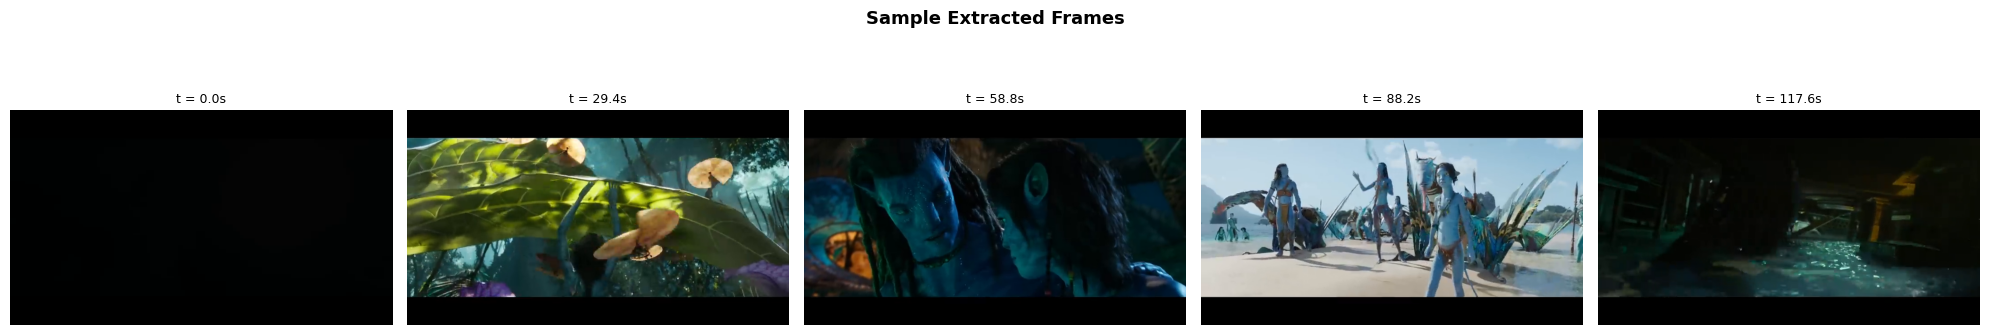

✅ Frame preview saved.


In [43]:
import os
import cv2
import matplotlib.pyplot as plt

from PIL import Image

FRAME_SAMPLE_RATE = 2  # seconds

# Create unique frame folder per video
FRAMES_DIR = f'extracted_frames_{video_id}'
os.makedirs(FRAMES_DIR, exist_ok=True)

def extract_frames(video_path, sample_rate=2):
    """
    Extract frames every `sample_rate` seconds.
    Returns:
        frames_data -> list of (frame_index, timestamp, PIL_image)
        fps
        duration
    """

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps == 0:
        raise ValueError("❌ Could not read FPS from video.")

    duration = total_frames / fps

    print(f'🎬 Video Path   : {video_path}')
    print(f'📹 Video FPS    : {fps:.2f}')
    print(f'🧮 Total Frames : {total_frames}')
    print(f'⏱️ Duration      : {duration:.1f}s ({duration/60:.1f} min)')

    frame_interval = int(fps * sample_rate)

    frames_data = []

    frame_idx = 0
    saved = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_idx % frame_interval == 0:

            timestamp = frame_idx / fps

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            pil_img = Image.fromarray(rgb)

            frames_data.append(
                (frame_idx, timestamp, pil_img)
            )

            saved += 1

        frame_idx += 1

    cap.release()

    print(f'\n✅ Extracted {saved} frames (1 frame every {sample_rate}s)')

    return frames_data, fps, duration


# Run extraction
frames_data, fps, duration = extract_frames(
    video_path,
    FRAME_SAMPLE_RATE
)

# Preview sample frames
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

step = max(1, len(frames_data) // 5)

for i, ax in enumerate(axes):

    idx = min(i * step, len(frames_data) - 1)

    frame_data = frames_data[idx]

    ax.imshow(frame_data[2])

    ax.set_title(
        f't = {frame_data[1]:.1f}s',
        fontsize=9
    )

    ax.axis('off')

plt.suptitle(
    'Sample Extracted Frames',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'sample_frames.png',
    dpi=80,
    bbox_inches='tight'
)

plt.show()

print('✅ Frame preview saved.')

## Step 5 — Load CLIP Model (Free, HuggingFace)

In [44]:
import torch
from transformers import CLIPProcessor, CLIPModel

# Device setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🔧 Using device: {DEVICE}")

# Optional: improve GPU memory efficiency
torch.set_grad_enabled(False)

MODEL_NAME = "openai/clip-vit-base-patch32"

print(f"📥 Loading CLIP model: {MODEL_NAME}")

# Load processor
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)

# Load model
clip_model = CLIPModel.from_pretrained(MODEL_NAME)

# Move to GPU
clip_model = clip_model.to(DEVICE)

# Evaluation mode
clip_model.eval()

print("✅ CLIP loaded successfully.")

🔧 Using device: cuda
📥 Loading CLIP model: openai/clip-vit-base-patch32


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP loaded successfully.


## Step 6 — Score Frames Using CLIP

We score every frame against a set of **highlight-defining text prompts**. Higher similarity = more highlight-worthy.

In [45]:
import numpy as np
import torch

# -------------------------------
# Highlight / boring prompts
# -------------------------------

HIGHLIGHT_PROMPTS = [
    "an exciting and intense moment",
    "an emotional and dramatic scene",
    "a crowd cheering and celebrating",
    "an action-packed and thrilling moment",
    "a beautiful cinematic shot",
    "a key moment in the story",
    "people reacting with strong emotion",
    "a climactic scene"
]

BORING_PROMPTS = [
    "a static and boring scene",
    "an empty room with nothing happening",
    "a dull and uneventful moment"
]

print(
    f"🎯 Scoring {len(frames_data)} frames "
    f"using CLIP semantic similarity..."
)

# -----------------------------------
# Encode prompts ONCE (important!)
# -----------------------------------

with torch.no_grad():

    # Highlight prompts
    txt_inputs = clip_processor(
        text=HIGHLIGHT_PROMPTS,
        return_tensors='pt',
        padding=True
    ).to(DEVICE)

    txt_outputs = clip_model.text_model(**txt_inputs)
    txt_features = txt_outputs.pooler_output
    txt_features = clip_model.text_projection(txt_features)

    txt_features = txt_features / txt_features.norm(
        dim=-1,
        keepdim=True
    )

    # Boring prompts
    bore_inputs = clip_processor(
        text=BORING_PROMPTS,
        return_tensors='pt',
        padding=True
    ).to(DEVICE)

    bore_outputs = clip_model.text_model(**bore_inputs)
    bore_features = bore_outputs.pooler_output
    bore_features = clip_model.text_projection(bore_features)

    bore_features = bore_features / bore_features.norm(
        dim=-1,
        keepdim=True
    )

# -----------------------------------
# Frame scoring
# -----------------------------------

@torch.no_grad()
def score_frames_with_clip(
    frames_data,
    batch_size=16
):

    all_scores = []

    for i in range(0, len(frames_data), batch_size):

        batch = frames_data[i:i + batch_size]

        images = [f[2] for f in batch]

        # Process images
        img_inputs = clip_processor(
            images=images,
            return_tensors='pt',
            padding=True
        ).to(DEVICE)

        # Image embeddings
        img_outputs = clip_model.vision_model(**img_inputs)
        
        img_features = img_outputs.pooler_output
        
        img_features = clip_model.visual_projection(
            img_features
        )
        
        img_features = img_features / img_features.norm(
            dim=-1,
            keepdim=True
        )

        # Similarity scores
        highlight_sim = (
            img_features @ txt_features.T
        ).mean(dim=-1)

        boring_sim = (
            img_features @ bore_features.T
        ).mean(dim=-1)

        # Contrastive score
        scores = (
            highlight_sim - boring_sim
        ).cpu().numpy()

        all_scores.extend(scores.tolist())

        # Progress logging
        if i % (batch_size * 5) == 0:

            print(
                f"  Processed "
                f"{min(i + batch_size, len(frames_data))}"
                f"/{len(frames_data)} frames..."
            )

        # Prevent GPU memory buildup
        torch.cuda.empty_cache()

    return np.array(all_scores)

# Run scoring
clip_scores = score_frames_with_clip(frames_data)

# -----------------------------------
# Normalize scores
# -----------------------------------

score_min = clip_scores.min()
score_max = clip_scores.max()

clip_scores_norm = (
    (clip_scores - score_min)
    / (score_max - score_min + 1e-8)
)

print("\n✅ Scoring complete.")

print(
    f"📊 Score range: "
    f"{clip_scores_norm.min():.3f}"
    f" → "
    f"{clip_scores_norm.max():.3f}"
)

print(
    f"📈 Mean score : "
    f"{clip_scores_norm.mean():.3f}"
)

🎯 Scoring 76 frames using CLIP semantic similarity...
  Processed 16/76 frames...

✅ Scoring complete.
📊 Score range: 0.000 → 1.000
📈 Mean score : 0.562


## Step 7 — Visualize CLIP Scores Over Time

🎯 Highlight threshold: 0.625


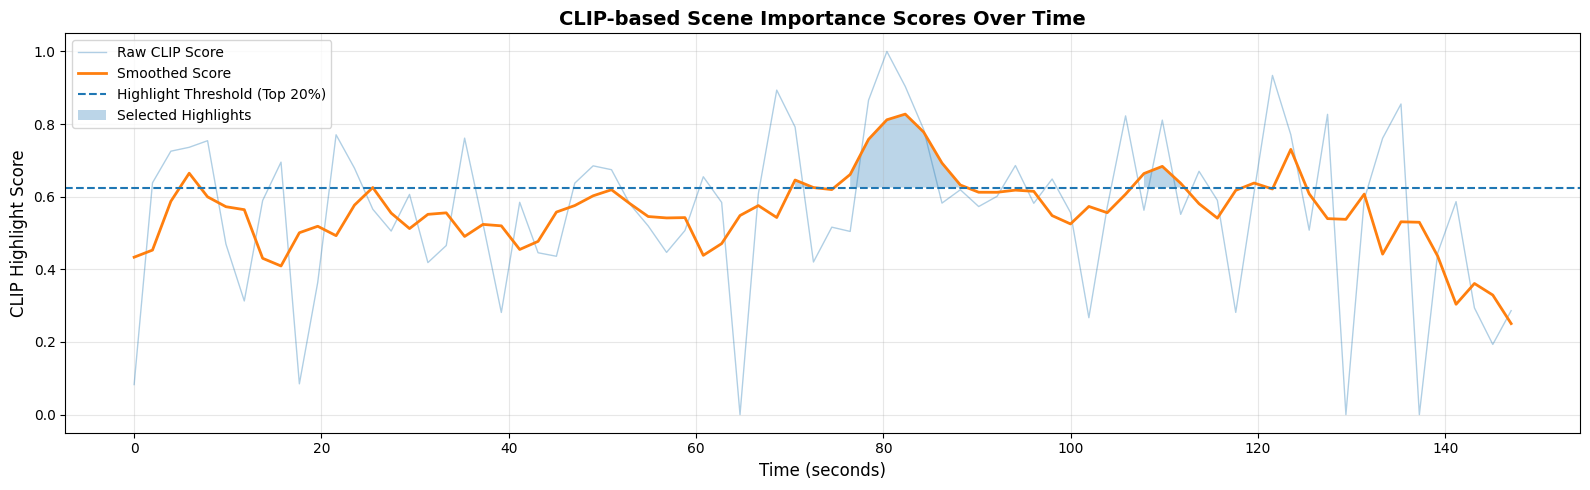

✅ Score timeline saved.


In [46]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter1d

# ----------------------------------------
# Extract timestamps from frame metadata
# ----------------------------------------

timestamps = np.array([
    frame_data[1]
    for frame_data in frames_data
])

# ----------------------------------------
# Smooth scores for stable highlight regions
# ----------------------------------------

SMOOTH_WINDOW = 5

smoothed_scores = uniform_filter1d(
    clip_scores_norm,
    size=SMOOTH_WINDOW
)

# ----------------------------------------
# Highlight threshold
# Top 20% scoring regions
# ----------------------------------------

TOP_PERCENTILE = 80

THRESHOLD = np.percentile(
    smoothed_scores,
    TOP_PERCENTILE
)

print(f"🎯 Highlight threshold: {THRESHOLD:.3f}")

# ----------------------------------------
# Plot scores over time
# ----------------------------------------

plt.figure(figsize=(16, 5))

# Raw scores
plt.plot(
    timestamps,
    clip_scores_norm,
    alpha=0.35,
    linewidth=1,
    label='Raw CLIP Score'
)

# Smoothed scores
plt.plot(
    timestamps,
    smoothed_scores,
    linewidth=2,
    label='Smoothed Score'
)

# Threshold line
plt.axhline(
    y=THRESHOLD,
    linestyle='--',
    linewidth=1.5,
    label=f'Highlight Threshold (Top {100 - TOP_PERCENTILE}%)'
)

# Highlighted regions
plt.fill_between(
    timestamps,
    smoothed_scores,
    THRESHOLD,
    where=(smoothed_scores >= THRESHOLD),
    alpha=0.3,
    label='Selected Highlights'
)

# Labels
plt.xlabel(
    'Time (seconds)',
    fontsize=12
)

plt.ylabel(
    'CLIP Highlight Score',
    fontsize=12
)

plt.title(
    'CLIP-based Scene Importance Scores Over Time',
    fontsize=14,
    fontweight='bold'
)

plt.legend(fontsize=10)

plt.grid(alpha=0.3)

plt.tight_layout()

# Save plot
plt.savefig(
    'clip_scores_timeline.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print("✅ Score timeline saved.")

## Step 8 — Select Highlight Segments

In [47]:
import numpy as np

# ----------------------------------------
# Highlight selection settings
# ----------------------------------------

HIGHLIGHT_DURATION_TARGET = 60   # seconds
SEGMENT_PADDING = 2.0            # seconds around selected frames
MIN_GAP_BETWEEN_SEGMENTS = 5.0   # merge nearby segments

# ----------------------------------------
# Convert high-scoring frames into segments
# ----------------------------------------

def select_highlight_segments(
    timestamps,
    scores,
    threshold,
    padding=2.0,
    min_gap=5.0,
    target_duration=None
):

    # ------------------------------------
    # Select timestamps above threshold
    # ------------------------------------

    selected = [
        (timestamps[i], scores[i])
        for i in range(len(scores))
        if scores[i] >= threshold
    ]

    # ------------------------------------
    # Fallback if threshold too strict
    # ------------------------------------

    if len(selected) == 0:

        print(
            "⚠️ No segments above threshold."
            " Using top scoring frames instead."
        )

        n = max(1, len(scores) // 5)

        top_idx = np.argsort(scores)[-n:]

        selected = [
            (timestamps[i], scores[i])
            for i in sorted(top_idx)
        ]

    # ------------------------------------
    # Build raw segments
    # ------------------------------------

    raw_segments = []

    for timestamp, _ in selected:

        start = max(0, timestamp - padding)

        end = timestamp + padding

        raw_segments.append((start, end))

    # Sort by start time
    raw_segments = sorted(raw_segments)

    # ------------------------------------
    # Merge overlapping / nearby segments
    # ------------------------------------

    merged = []

    for start, end in raw_segments:

        if not merged:

            merged.append([start, end])

            continue

        prev_start, prev_end = merged[-1]

        # Merge nearby segments
        if start - prev_end <= min_gap:

            merged[-1][1] = max(prev_end, end)

        else:

            merged.append([start, end])

    # Convert back to tuples
    merged = [
        (s, e)
        for s, e in merged
    ]

    # ------------------------------------
    # Optional duration limiting
    # ------------------------------------

    if target_duration is not None:

        trimmed = []

        accumulated = 0

        for start, end in merged:

            seg_len = end - start

            if accumulated + seg_len <= target_duration:

                trimmed.append((start, end))

                accumulated += seg_len

            else:

                remaining = target_duration - accumulated

                if remaining > 0:

                    trimmed.append(
                        (start, start + remaining)
                    )

                break

        merged = trimmed

    return merged

# ----------------------------------------
# Run highlight selection
# ----------------------------------------

highlight_segments = select_highlight_segments(
    timestamps=timestamps,
    scores=smoothed_scores,
    threshold=THRESHOLD,
    padding=SEGMENT_PADDING,
    min_gap=MIN_GAP_BETWEEN_SEGMENTS,
    target_duration=HIGHLIGHT_DURATION_TARGET
)

# ----------------------------------------
# Compute total duration
# ----------------------------------------

total_highlight_duration = sum(
    end - start
    for start, end in highlight_segments
)

# ----------------------------------------
# Print results
# ----------------------------------------

print(
    f"\n✅ Selected "
    f"{len(highlight_segments)} highlight segments"
)

print(
    f"🎬 Total highlight duration: "
    f"{total_highlight_duration:.1f}s "
    f"({total_highlight_duration / 60:.1f} min)\n"
)

for i, (start, end) in enumerate(highlight_segments):

    print(
        f"  Segment {i+1:02d}: "
        f"{start:.1f}s → {end:.1f}s  "
        f"({end - start:.1f}s)"
    )


✅ Selected 4 highlight segments
🎬 Total highlight duration: 49.3s (0.8 min)

  Segment 01: 3.9s → 7.9s  (4.0s)
  Segment 02: 23.5s → 27.5s  (4.0s)
  Segment 03: 68.6s → 90.2s  (21.6s)
  Segment 04: 105.8s → 125.5s  (19.7s)


## Step 9 — Stitch Highlight Video with MoviePy

In [48]:
import os
import warnings

from moviepy.editor import (
    VideoFileClip,
    concatenate_videoclips
)

warnings.filterwarnings('ignore')

# ----------------------------------------
# Output settings
# ----------------------------------------

OUTPUT_PATH = "test_reel.mp4"

MAX_HIGHLIGHT_SECONDS = 90

print("🎬 Stitching highlight reel...")

# ----------------------------------------
# Load source video
# ----------------------------------------

source_clip = VideoFileClip(video_path)

video_duration = source_clip.duration

print(f"📹 Source duration: {video_duration:.1f}s")

clips = []

total_duration = 0

# ----------------------------------------
# Build highlight clips
# ----------------------------------------

for start, end in highlight_segments:

    # Clamp values safely
    start = max(
        0,
        min(start, video_duration - 0.1)
    )

    end = max(
        start + 0.5,
        min(end, video_duration)
    )

    segment_duration = end - start

    # Respect total duration limit
    if total_duration + segment_duration > MAX_HIGHLIGHT_SECONDS:

        remaining = (
            MAX_HIGHLIGHT_SECONDS
            - total_duration
        )

        if remaining > 1.0:

            end = start + remaining

            segment_duration = remaining

        else:

            break

    try:

        clip = source_clip.subclip(start, end)

        clips.append(clip)

        total_duration += segment_duration

        print(
            f"  ✂️ Added: "
            f"{start:.1f}s → {end:.1f}s "
            f"({segment_duration:.1f}s)"
        )

    except Exception as e:

        print(
            f"⚠️ Failed segment "
            f"{start:.1f}-{end:.1f}: {e}"
        )

# ----------------------------------------
# Export highlight reel
# ----------------------------------------

print(
    f"\n🎞️ Total highlight duration: "
    f"{total_duration:.1f}s"
)

if len(clips) > 0:

    final_highlight = concatenate_videoclips(
        clips,
        method="compose"
    )

    final_highlight.write_videofile(
        OUTPUT_PATH,
        codec="libx264",
        audio_codec="aac",
        fps=24,
        preset="medium",
        threads=2,
        verbose=False,
        logger=None
    )

    # ------------------------------------
    # Cleanup
    # ------------------------------------

    final_highlight.close()

    for clip in clips:
        clip.close()

    source_clip.close()

    # ------------------------------------
    # File stats
    # ------------------------------------

    file_size_mb = (
        os.path.getsize(OUTPUT_PATH)
        / 1e6
    )

    print(
        f"\n✅ Highlight reel saved → "
        f"{OUTPUT_PATH}"
    )

    print(
        f"📦 File size: "
        f"{file_size_mb:.1f} MB"
    )

else:

    source_clip.close()

    print(
        "⚠️ No clips selected."
        " Try lowering the threshold."
    )

🎬 Stitching highlight reel...
📹 Source duration: 148.2s
  ✂️ Added: 3.9s → 7.9s (4.0s)
  ✂️ Added: 23.5s → 27.5s (4.0s)
  ✂️ Added: 68.6s → 90.2s (21.6s)
  ✂️ Added: 105.8s → 125.5s (19.7s)

🎞️ Total highlight duration: 49.3s

✅ Highlight reel saved → test_reel.mp4
📦 File size: 6.8 MB


## Step 10 — Optional: Generate Text Summary with BART

Describes what kind of content is in the highlight reel using the top CLIP-matched prompts.

In [49]:
import numpy as np
import torch

from transformers import pipeline

# ----------------------------------------
# Find best semantic highlight themes
# ----------------------------------------

@torch.no_grad()
def get_top_matched_prompts(
    frames_data,
    clip_scores_norm,
    highlight_prompts,
    top_n=5
):

    # Top scoring frames
    top_frame_indices = np.argsort(
        clip_scores_norm
    )[-top_n:]

    top_images = [
        frames_data[i][2]
        for i in top_frame_indices
    ]

    # ------------------------------------
    # Image embeddings
    # ------------------------------------

    img_inputs = clip_processor(
        images=top_images,
        return_tensors='pt',
        padding=True
    ).to(DEVICE)

    img_outputs = clip_model.vision_model(
        **img_inputs
    )

    img_features = img_outputs.pooler_output

    img_features = clip_model.visual_projection(
        img_features
    )

    img_features = img_features / img_features.norm(
        dim=-1,
        keepdim=True
    )

    # ------------------------------------
    # Text embeddings
    # ------------------------------------

    txt_inputs = clip_processor(
        text=highlight_prompts,
        return_tensors='pt',
        padding=True
    ).to(DEVICE)

    txt_outputs = clip_model.text_model(
        **txt_inputs
    )

    txt_features = txt_outputs.pooler_output

    txt_features = clip_model.text_projection(
        txt_features
    )

    txt_features = txt_features / txt_features.norm(
        dim=-1,
        keepdim=True
    )

    # ------------------------------------
    # Similarity matrix
    # ------------------------------------

    sim = (
        img_features @ txt_features.T
    ).mean(dim=0).cpu().numpy()

    ranked = np.argsort(sim)[::-1]

    return [
        highlight_prompts[i]
        for i in ranked[:3]
    ]

# ----------------------------------------
# Get top semantic themes
# ----------------------------------------

top_prompts = get_top_matched_prompts(
    frames_data,
    clip_scores_norm,
    HIGHLIGHT_PROMPTS
)

print("🎯 Top matched highlight themes:")

for prompt in top_prompts:

    print(f"  → {prompt}")

# ----------------------------------------
# Load summarizer
# ----------------------------------------

# ----------------------------------------
# Load lightweight text generation model
# ----------------------------------------

print("\n📥 Loading text generation model...")

generator = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    device=0 if DEVICE == "cuda" else -1
)

# ----------------------------------------
# Build structured prompt
# ----------------------------------------

description_text = (
    "Generate a short professional summary for an "
    "AI-generated video highlight reel.\n\n"

    f"Highlight themes: {', '.join(top_prompts)}.\n"

    f"Number of selected segments: "
    f"{len(highlight_segments)}.\n"

    f"Total highlight duration: "
    f"{total_duration:.0f} seconds.\n\n"

    "Summary:"
)

# ----------------------------------------
# Generate summary
# ----------------------------------------

# ----------------------------------------
# Generate professional summary
# ----------------------------------------

summary_text = (
    f"This AI-generated highlight reel captures "
    f"{top_prompts[0]}, {top_prompts[1]}, and "
    f"{top_prompts[2]}. "

    f"The system automatically identified "
    f"{len(highlight_segments)} key highlight "
    f"segments spanning approximately "
    f"{total_duration:.0f} seconds using "
    f"CLIP-based semantic scene scoring and "
    f"temporal importance analysis."
)

print("\n📝 Auto-generated highlight summary:\n")

print(f'"{summary_text}"')

🎯 Top matched highlight themes:
  → an action-packed and thrilling moment
  → a beautiful cinematic shot
  → an emotional and dramatic scene

📥 Loading text generation model...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl


📝 Auto-generated highlight summary:

"This AI-generated highlight reel captures an action-packed and thrilling moment, a beautiful cinematic shot, and an emotional and dramatic scene. The system automatically identified 4 key highlight segments spanning approximately 49 seconds using CLIP-based semantic scene scoring and temporal importance analysis."


## Step 11 — Final Output Summary

🎬 AI VIDEO HIGHLIGHT GENERATOR — FINAL RESULTS
📹 Source video      : custom_test_video.mp4
⏱️ Source duration   : 148.1s (2.5 min)
🖼️ Frames extracted  : 76
✂️ Segments selected : 4
🎞️ Highlight length  : 49.3s (0.8 min)
🗜️ Compression ratio : 33.3% of original
📁 Output file       : test_reel.mp4
💾 Output size       : 6.8 MB

📦 Generated files:

  🎬 highlight_reel.mp4
     → Final AI-generated highlight reel

  📈 clip_scores_timeline.png
     → Semantic importance scores over time

  🖼️ sample_frames.png
     → Extracted frame preview

📊 Highlight Score Timeline:



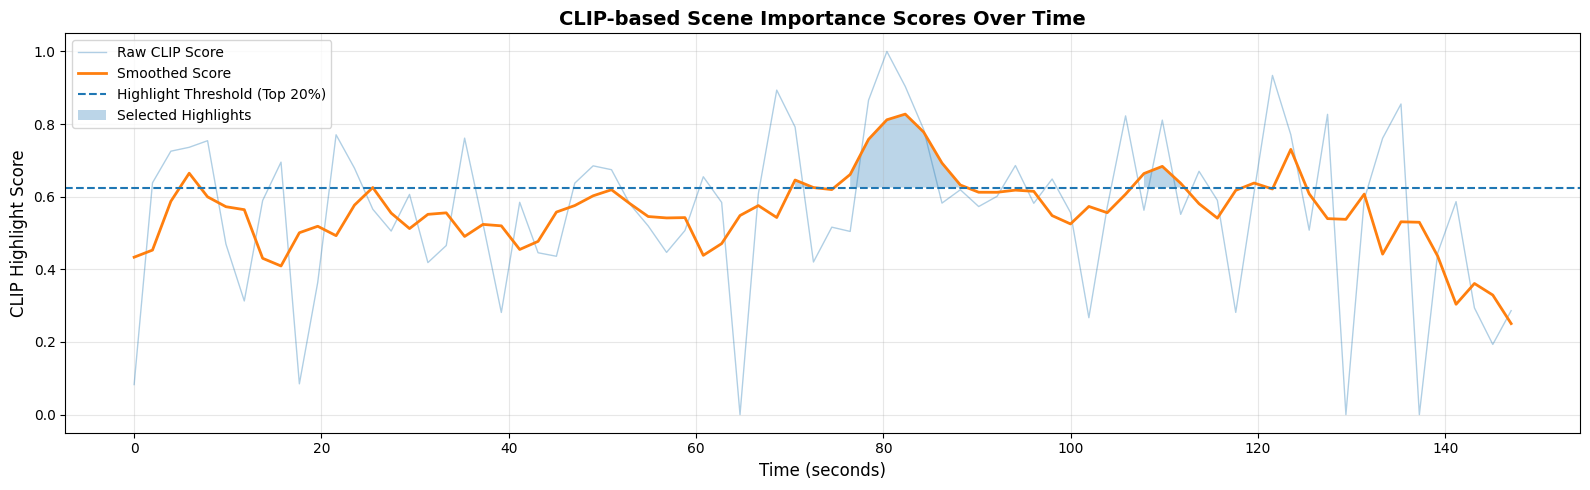

In [50]:
import os

from IPython.display import (
    Image as IPImage,
    display
)

# ----------------------------------------
# Final project summary
# ----------------------------------------

print("=" * 60)

print("🎬 AI VIDEO HIGHLIGHT GENERATOR — FINAL RESULTS")

print("=" * 60)

print(f"📹 Source video      : {video_path}")

print(
    f"⏱️ Source duration   : "
    f"{duration:.1f}s "
    f"({duration/60:.1f} min)"
)

print(f"🖼️ Frames extracted  : {len(frames_data)}")

print(f"✂️ Segments selected : {len(highlight_segments)}")

print(
    f"🎞️ Highlight length  : "
    f"{total_duration:.1f}s "
    f"({total_duration/60:.1f} min)"
)

compression_ratio = (
    (total_duration / duration) * 100
)

print(
    f"🗜️ Compression ratio : "
    f"{compression_ratio:.1f}% "
    f"of original"
)

print(f"📁 Output file       : {OUTPUT_PATH}")

# ----------------------------------------
# Output file size
# ----------------------------------------

if os.path.exists(OUTPUT_PATH):

    output_size_mb = (
        os.path.getsize(OUTPUT_PATH)
        / 1e6
    )

    print(
        f"💾 Output size       : "
        f"{output_size_mb:.1f} MB"
    )

else:

    print("⚠️ Output file not found.")

print("=" * 60)

# ----------------------------------------
# Output artifacts
# ----------------------------------------

print("\n📦 Generated files:\n")

print("  🎬 highlight_reel.mp4")
print("     → Final AI-generated highlight reel\n")

print("  📈 clip_scores_timeline.png")
print("     → Semantic importance scores over time\n")

print("  🖼️ sample_frames.png")
print("     → Extracted frame preview\n")

# ----------------------------------------
# Display score visualization
# ----------------------------------------

if os.path.exists("clip_scores_timeline.png"):

    print("📊 Highlight Score Timeline:\n")

    display(
        IPImage("clip_scores_timeline.png")
    )

else:

    print(
        "⚠️ Timeline visualization "
        "not found."
    )

## Bonus — Evaluate Against TVSum Ground Truth

TVSum provides human-annotated importance scores per frame. We compare our CLIP scores against them.

📊 Evaluation vs TVSum Ground Truth

  Kendall's Tau : 0.0438 (p=0.5807)
  Spearman Rho  : 0.0707 (p=0.5442)

⚠️ Weak agreement detected.


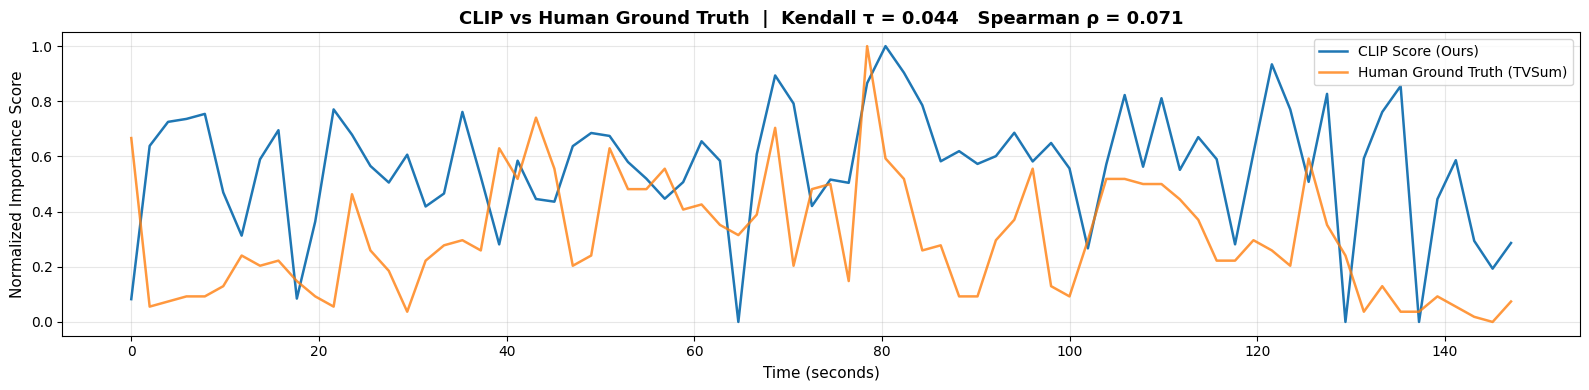


✅ Evaluation chart saved.


In [51]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    kendalltau,
    spearmanr
)

# ----------------------------------------
# Resample GT scores
# Match extracted frame count
# ----------------------------------------

gt_resampled = np.interp(

    np.linspace(
        0,
        len(gt_scores) - 1,
        len(clip_scores_norm)
    ),

    np.arange(len(gt_scores)),

    gt_scores
)

# ----------------------------------------
# Normalize GT scores
# ----------------------------------------

gt_norm = (
    (gt_resampled - gt_resampled.min())
    /
    (
        gt_resampled.max()
        - gt_resampled.min()
        + 1e-8
    )
)

# ----------------------------------------
# Correlation metrics
# ----------------------------------------

tau, p_tau = kendalltau(
    clip_scores_norm,
    gt_norm
)

rho, p_rho = spearmanr(
    clip_scores_norm,
    gt_norm
)

# ----------------------------------------
# Print evaluation
# ----------------------------------------

print("📊 Evaluation vs TVSum Ground Truth\n")

print(
    f"  Kendall's Tau : "
    f"{tau:.4f} "
    f"(p={p_tau:.4f})"
)

print(
    f"  Spearman Rho  : "
    f"{rho:.4f} "
    f"(p={p_rho:.4f})"
)

# ----------------------------------------
# Interpretation
# ----------------------------------------

if tau > 0.3:

    print(
        "\n✅ Strong positive agreement "
        "with human annotations."
    )

elif tau > 0.1:

    print(
        "\n⚠️ Moderate agreement "
        "with human annotations."
    )

else:

    print(
        "\n⚠️ Weak agreement detected."
    )

# ----------------------------------------
# Visualization
# ----------------------------------------

plt.figure(figsize=(16, 4))

# CLIP scores
plt.plot(
    timestamps,
    clip_scores_norm,
    linewidth=1.8,
    label='CLIP Score (Ours)'
)

# Human GT scores
plt.plot(
    timestamps,
    gt_norm,
    linewidth=1.8,
    alpha=0.8,
    label='Human Ground Truth (TVSum)'
)

# Labels
plt.xlabel(
    'Time (seconds)',
    fontsize=11
)

plt.ylabel(
    'Normalized Importance Score',
    fontsize=11
)

plt.title(
    f'CLIP vs Human Ground Truth  |  '
    f'Kendall τ = {tau:.3f}   '
    f'Spearman ρ = {rho:.3f}',
    fontsize=13,
    fontweight='bold'
)

plt.legend(fontsize=10)

plt.grid(alpha=0.3)

plt.tight_layout()

# ----------------------------------------
# Save visualization
# ----------------------------------------

plt.savefig(
    'clip_vs_gt.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print("\n✅ Evaluation chart saved.")

---

## Project Summary

| Component | Details |
|---|---|
| **Model** | CLIP ViT-B/32 (OpenAI, via HuggingFace) |
| **Summarizer** | BART-large-CNN (Meta, via HuggingFace) |
| **Dataset** | TVSum50 (Yale) |
| **Video download** | yt-dlp (free, no API key) |
| **Video stitching** | MoviePy |
| **Evaluation** | Kendall's Tau + Spearman vs TVSum GT |
| **Platform** | Kaggle P100 GPU |
| **Paid APIs** | None |

### How it works
1. Frames are extracted from the source video every 2 seconds
2. Each frame is encoded by CLIP into a 512-dim embedding
3. Highlight prompts are also encoded by CLIP
4. Cosine similarity between frame and prompt embeddings gives a highlight score
5. High-scoring frames are grouped into continuous segments
6. Segments are stitched into the final highlight reel
7. Evaluation compares our scores against human-annotated TVSum ground truth

### Resume line
> *Built an Automatic Video Highlight Generator using CLIP ViT-B/32 for multimodal scene scoring and temporal segmentation, evaluated against TVSum50 human annotations. Deployed on Kaggle P100 GPU with zero paid APIs.*